In [1]:
###
### --- STUDENT PERFORMANCE PREDICTION --- ###
"""
Early predictive classification model that estimates the probability of student academic failure based on socio-academic factors
(Early prediction of student academic failure risk)
"""
###

'\nEarly predictive classification model that estimates the probability of student academic failure based on socio-academic factors\n(Early prediction of student academic failure risk)\n'

In [2]:
import sys
print(sys.executable)

/opt/anaconda3/envs/stats/bin/python


In [3]:
import numpy as np
import pandas as pd
import matplotlib as mtpl
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set(style="whitegrid")

%load_ext autoreload
%autoreload 2

print("\tPython ",sys.version)
print("\tpandas: ",pd.__version__)
print("\tnumpy: ",np.__version__)
print("\tmatplotlib: ",mtpl.__version__)

	Python  3.11.14 (main, Oct 21 2025, 18:27:30) [Clang 20.1.8 ]
	pandas:  2.3.3
	numpy:  2.4.2
	matplotlib:  3.10.7


In [4]:
df_mat = pd.read_csv("data-student/student-mat.csv", sep=";")
df_por = pd.read_csv("data-student/student-por.csv", sep=";")

In [5]:
# first 5 lines of dataset 
df_mat.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
df_mat.shape

(395, 33)

In [7]:
df_mat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [8]:
df_mat.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [9]:
# target variable - detect risk 
df_mat["risk"] = (df_mat["G3"] < 10).astype(int)
df_mat["risk"].value_counts()
# G3 >= 10 => Success(0) - Risk = 0 False
# G3 < 10 => Fail(1) - Risk = 1 True 

risk
0    265
1    130
Name: count, dtype: int64

In [10]:
# percentage
df_mat["risk"].value_counts(normalize=True)

risk
0    0.670886
1    0.329114
Name: proportion, dtype: float64

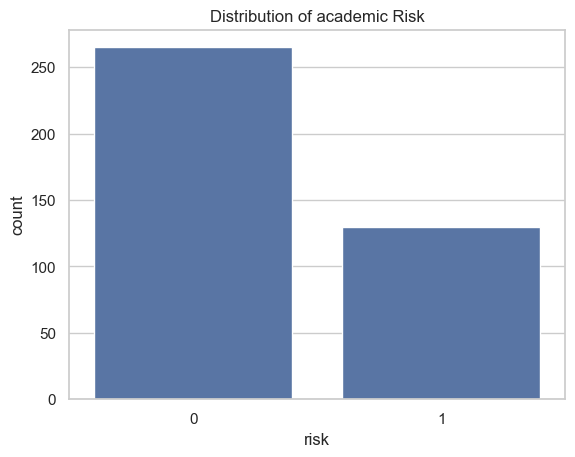

In [11]:
sns.countplot(x="risk", data=df_mat)
plt.title("Distribution of academic Risk")
plt.show()

<Axes: xlabel='studytime', ylabel='Count'>

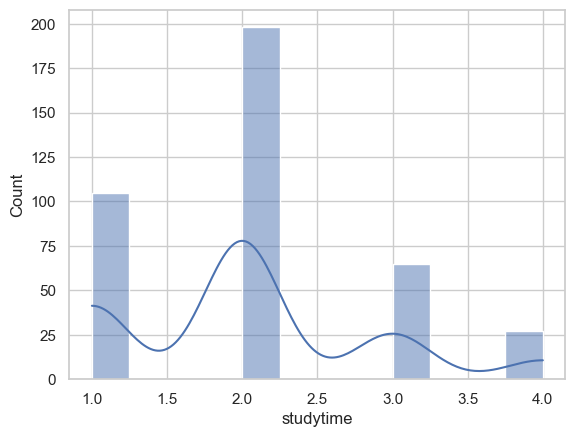

In [27]:
# Potentially strong predictors: studytime, (previous) failures, absences, G1, G2
# show which variables correlate risk classes

# studytime
sns.histplot(df_mat["studytime"], kde=True)

<Axes: xlabel='risk', ylabel='studytime'>

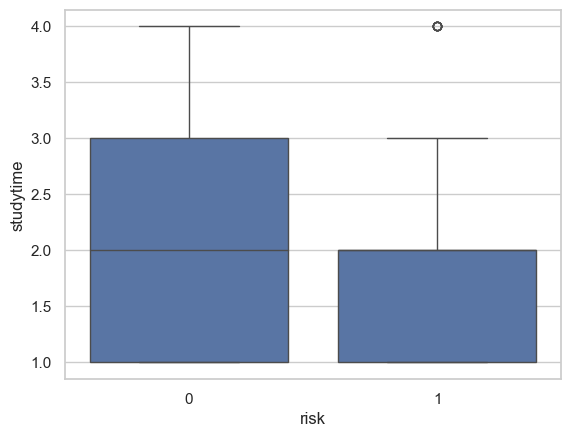

In [13]:
sns.boxplot(x="risk", y="studytime", data=df_mat)

<Axes: xlabel='failures', ylabel='Count'>

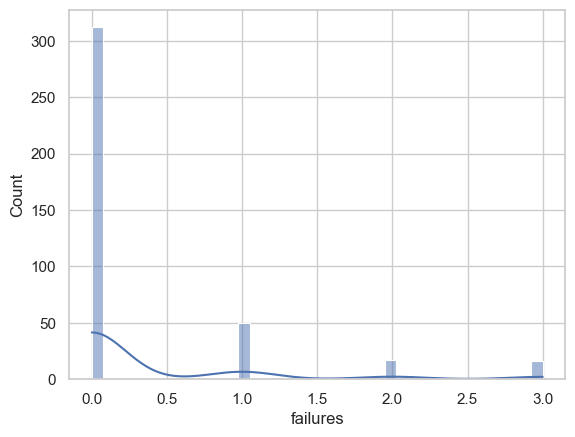

In [14]:
# (previous) failures
sns.histplot(df_mat["failures"], kde=True)

<Axes: xlabel='risk', ylabel='failures'>

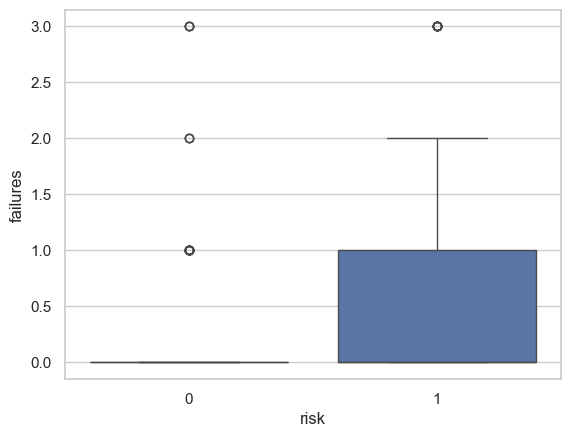

In [15]:
sns.boxplot(x="risk", y="failures", data=df_mat)

<Axes: xlabel='absences', ylabel='Count'>

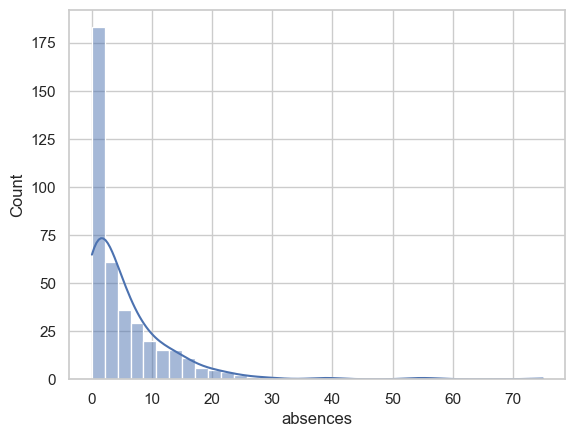

In [16]:
# absences
sns.histplot(df_mat["absences"], kde=True)

<Axes: xlabel='risk', ylabel='absences'>

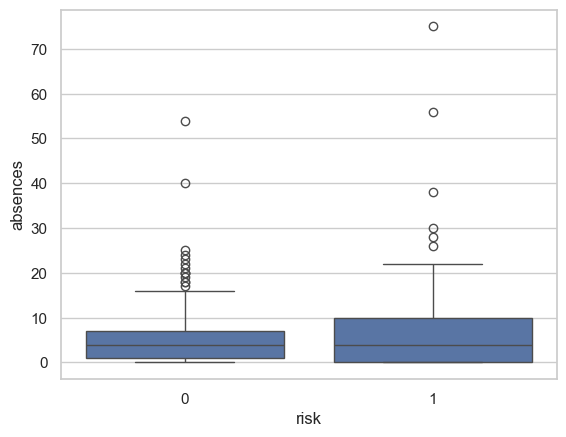

In [17]:
sns.boxplot(x="risk", y="absences", data=df_mat)

<Axes: xlabel='G1', ylabel='Count'>

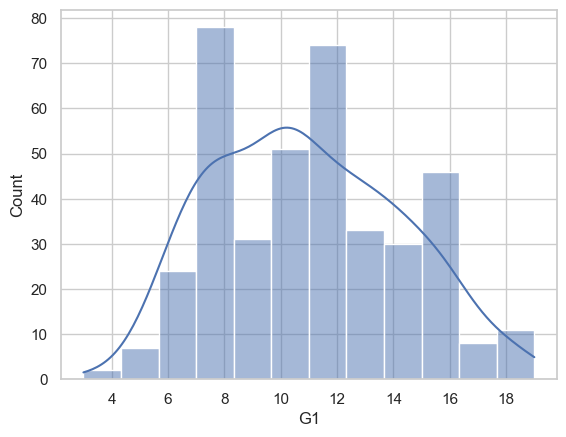

In [18]:
# G1
sns.histplot(df_mat["G1"], kde=True)

<Axes: xlabel='risk', ylabel='G1'>

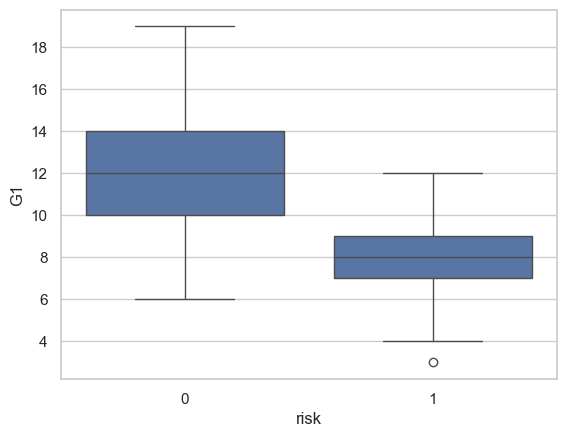

In [19]:
sns.boxplot(x="risk", y="G1", data=df_mat)

<Axes: xlabel='G2', ylabel='Count'>

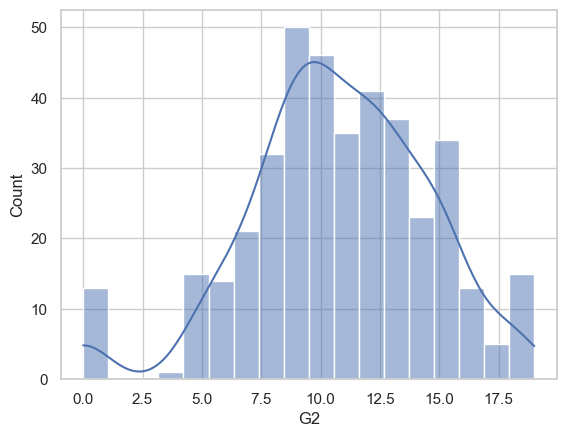

In [20]:
# G2
sns.histplot(df_mat["G2"], kde=True)

<Axes: xlabel='risk', ylabel='G2'>

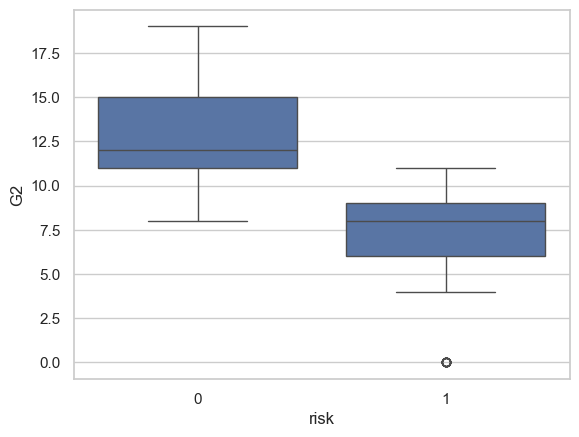

In [21]:
sns.boxplot(x="risk", y="G2", data=df_mat)

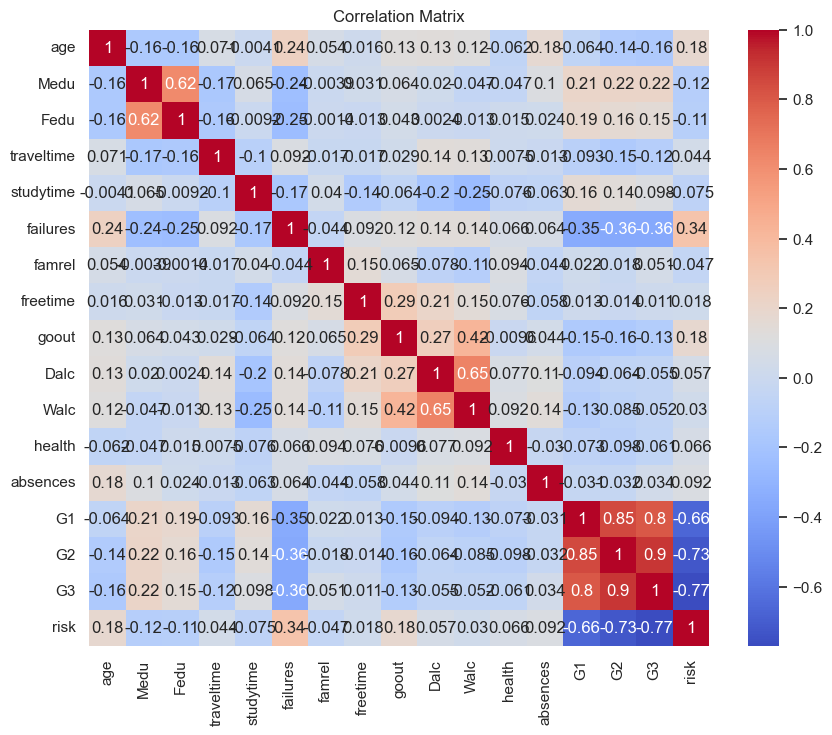

In [22]:
# check correlation between (studytime, (previous) failures, absences, G1, G2) vs G3
plt.figure(figsize=(10,8))
sns.heatmap(df_mat.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='higher', ylabel='count'>

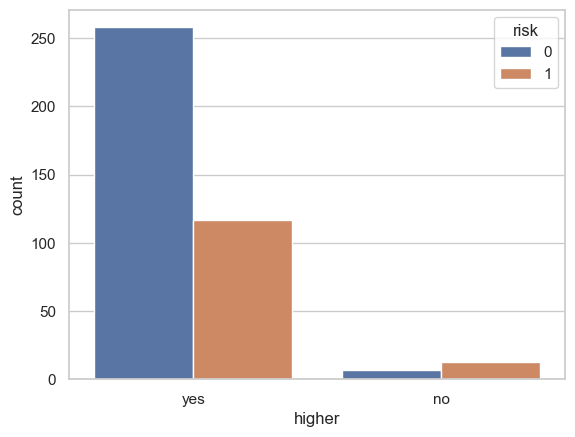

In [23]:
# categorical variables
# do students want higher education fail less?
sns.countplot(x="higher", hue="risk", data=df_mat)

<Axes: xlabel='famsup', ylabel='count'>

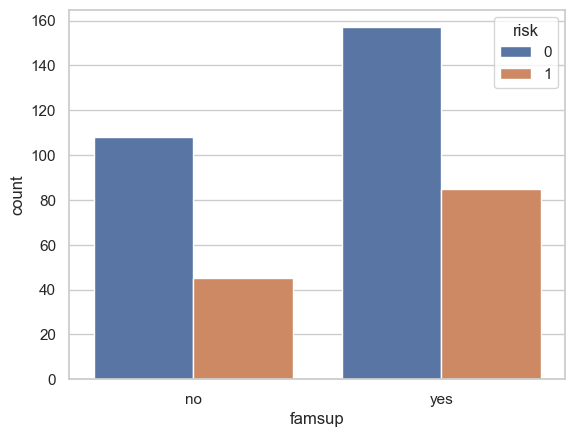

In [24]:
# do students with famsup fail less?
sns.countplot(x="famsup", hue="risk", data=df_mat)

In [32]:
# compare means by risk (optional)
# average differences between risk groups
df_mat.groupby("risk").mean(numeric_only=True)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
risk,,,,,,,,,,,,,,,,
0,16.535849,2.837736,2.603774,1.426415,2.079245,0.158491,3.973585,3.222642,2.966038,1.445283,2.264151,3.490566,5.192453,12.452830,12.622642,12.883019
1,17.023077,2.569231,2.353846,1.492308,1.946154,0.692308,3.884615,3.261538,3.400000,1.553846,2.346154,3.684615,6.761538,7.761538,6.823077,5.384615


In [31]:
df_mat.corr(numeric_only=True)["G3"].sort_values(ascending=False)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
risk         -0.770042
Name: G3, dtype: float64